# NASDAQ-100 Microstructure: Temporal Features

**Chapter 9: Time Series Analysis**

This notebook constructs temporal features for the NASDAQ-100 Microstructure
case study using three complementary approaches: HAR volatility decomposition,
FFT spectral analysis on intraday volume profiles, and path signatures over
recent price-volume trajectories.

**Learning Objectives**:
- Fit the HAR(5,15,60) model on intraday realized volatility (walk-forward)
- Extract rolling FFT spectral features from volume and volatility series
- Compute depth-2 path signatures on (price, signed_vol, trades) trajectories
- Combine temporal features with Ch8 cross-sectional features for modeling

**Temporal Models**:

| Model | Role | Output Features |
|-------|------|-----------------|
| HAR(5,15,60) | Primary | Conditional vol forecast, HAR residual |
| FFT/Spectral | Primary | Spectral energy, dominant period, entropy |
| Path Signatures | Primary | Depth-2 signature terms (6 features per path) |

**Walk-Forward Discipline**:
- HAR coefficients fitted on rolling OLS windows within each symbol
- FFT features use only past data (causal rolling windows)
- Signatures computed on trailing 30-minute windows (no future leakage)

**Output Contract**:
- `features/model_based.parquet` -- temporal feature matrix with `fold` column for per-fold CV

**Cross-References**:
- **Upstream**: Ch8 (`03_financial_features.py` for features), Ch7 ([`02_labels`](02_labels.ipynb) for prices)
- **Downstream**: Ch11+ (models)
- **Teaching**: [`09_har_rough_volatility`](../../09_model_based_features/09_har_rough_volatility.ipynb), [`05_spectral_features`](../../09_model_based_features/05_spectral_features.ipynb),
  [`06_path_signatures`](../../09_model_based_features/06_path_signatures.ipynb)

In [1]:
"""NASDAQ-100 Microstructure: Temporal Features (Ch9)."""

import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from data import load_nasdaq100_bars
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "nasdaq100_microstructure"
START_DATE = "2020-01-01"
END_DATE = "2021-12-31"
MAX_SYMBOLS = 0

In [3]:
# Configuration
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
FEATURES_DIR = CASE_DIR / "features"

SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
EVAL_CFG = load_evaluation_config(CASE_STUDY_ID)
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
HOLDOUT_START = pd.Timestamp(EVAL_CFG["holdout_start"])
HOLDOUT_END = pd.Timestamp(EVAL_CFG["holdout_end"])

# The bar is one minute, so the label horizon and the IC sampling step are both
# expressed in bars and derived from the configured buffer rather than typed.
BAR = pd.Timedelta(minutes=1)
LABEL_HORIZON_BARS = int(pd.Timedelta(LABEL_BUFFER) // BAR)
IC_SAMPLE_STEP = LABEL_HORIZON_BARS  # thin to one decision per label horizon


def iso(value: object) -> str:
    """Date-like -> ISO string, for anything handed to Plotly.

    Plotly stores layout shape coordinates verbatim, and kaleido serialises the
    figure spec with orjson, which has no encoder for pandas.Timestamp. A figure
    built with Timestamps renders in a browser and raises
    "Type is not JSON serializable: Timestamp" at export time - i.e. it fails on
    the run that matters, not on the one you are watching.
    """
    return pd.Timestamp(value).isoformat()


# Estimation windows for the three fitted models, in bars. Declared once here;
# nothing below re-types them.
HAR_COMPONENTS = (5, 15, 60)
HAR_FIT_WINDOW = 120
FFT_WINDOW = 60
SIG_WINDOW = 30

print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Label: {PRIMARY_LABEL}, buffer {LABEL_BUFFER} ({LABEL_HORIZON_BARS} bars)")
print(f"Holdout: {HOLDOUT_START.date()} .. {HOLDOUT_END.date()}")
if MAX_SYMBOLS:
    print(f"Symbol limit: {MAX_SYMBOLS}")

Date range: 2020-01-01 to 2021-12-31
Label: fwd_ret_15m, buffer 15min (15 bars)
Holdout: 2021-07-01 .. 2021-12-31


## 1. Load and Prepare Data

Load minute bars with microstructure fields. We need the same raw data as
`03_financial_features.py` to compute temporal features from time-series models
applied to volatility, volume, and price paths.

In [4]:
df = load_nasdaq100_bars(
    start_date=START_DATE,
    end_date=str(END_DATE),
    include_microstructure=True,
)

# Optionally restrict universe
if MAX_SYMBOLS:
    top_syms = (
        df.group_by("symbol")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(MAX_SYMBOLS)["symbol"]
        .to_list()
    )
    df = df.filter(pl.col("symbol").is_in(top_syms))
    print(f"Restricted to {MAX_SYMBOLS} symbols: {top_syms}")

# Filter to regular trading hours
df = df.filter(
    (pl.col("timestamp").dt.hour() >= 10)
    | ((pl.col("timestamp").dt.hour() == 9) & (pl.col("timestamp").dt.minute() >= 30))
)
df = df.filter(pl.col("timestamp").dt.hour() < 16)

# Sort and add session_date
df = df.sort(["symbol", "timestamp"])
df = df.with_columns(pl.col("timestamp").dt.date().alias("session_date"))

print(f"Loaded {len(df):,} minute bars")
print(f"Symbols: {df['symbol'].n_unique()}, Sessions: {df['session_date'].n_unique()}")

Loaded 19,908,044 minute bars
Symbols: 114, Sessions: 505


### Derived Fields

Compute midprice, log returns, signed volume, and bar-of-day from raw minute bars.

In [5]:

# Compute midprice and basic fields needed for temporal features
mid = (pl.col("close_bid_price") + pl.col("close_ask_price")) / 2
df = df.with_columns(mid_close=mid)
df = df.filter(pl.col("mid_close").is_not_null() & (pl.col("mid_close") > 0))

# 1-minute log mid return (session-bounded)
group_cols = ["symbol", "session_date"]
df = df.with_columns(
    r1m=(pl.col("mid_close").log() - pl.col("mid_close").log().shift(1).over(group_cols))
)

# Signed volume for path signatures
signed_vol = (pl.col("trade_at_ask") + pl.col("trade_at_mid_ask")) - (
    pl.col("trade_at_bid") + pl.col("trade_at_bid_mid")
)
df = df.with_columns(
    signed_vol=signed_vol,
    signed_vol_share=(signed_vol / pl.col("volume").clip(lower_bound=1)),
)

# Bar-of-day for session position
df = df.with_columns(
    bar_of_day=pl.col("timestamp").rank("ordinal").over(group_cols).cast(pl.Int32) - 1,
)

## 2. HAR(5,15,60) Volatility Model

The Heterogeneous Autoregressive (HAR) model (Corsi, 2009) decomposes
realized volatility into components at different horizons, reflecting
the heterogeneous behavior of market participants:

$$RV_{t+1}^{(5)} = c + \beta_5 \, RV_t^{(5)} + \beta_{15} \, RV_t^{(15)} + \beta_{60} \, RV_t^{(60)} + \varepsilon_{t+1}$$

For intraday microstructure data, we use 5-minute, 15-minute, and 60-minute
realized volatility components (instead of the standard daily/weekly/monthly
decomposition). The HAR residual is a useful feature: positive residuals
indicate realized vol exceeded the model forecast (surprise volatility).

**Walk-forward**: HAR coefficients are fitted on a rolling 120-bar
fixed window within each symbol using OLS.

**Session boundary note**: HAR regressors are computed across all sessions
concatenated per symbol. Overnight gaps appear as zero-return bars (via
`nan_to_num`), which biases windows that span overnight gaps. A row is affected
when its trailing window reaches back past the session open, so the affected
share is the window length divided by the session length and grows with the
window. The next cell measures it for the three windows this notebook uses.
A production system would use session-bounded windowing (as in
`03_financial_features.py`); here we accept the approximation for teaching
clarity. Note that `r1m` itself is session-bounded — the contamination is
only in the aggregation windows.

`bar_of_day` is the position within the session, so a row with
`bar_of_day < window` is one whose trailing window reaches back across the
overnight gap. That makes the affected share something to measure rather than
assert.

In [6]:
print("Rows whose trailing window crosses a session boundary:")
for _name, _w in [
    ("signatures", SIG_WINDOW),
    ("FFT", FFT_WINDOW),
    ("HAR regressors", HAR_COMPONENTS[-1]),
    ("HAR fit window", HAR_FIT_WINDOW),
]:
    _share = df.select((pl.col("bar_of_day") < _w).mean()).item()
    print(f"  {_name:<16s} ({_w:>3d}-bar): {_share:6.1%}")

Rows whose trailing window crosses a session boundary:
  signatures       ( 30-bar):   7.7%
  FFT              ( 60-bar):  15.4%
  HAR regressors   ( 60-bar):  15.4%
  HAR fit window   (120-bar):  30.8%


In [7]:
def build_har_features_intraday(
    r1m: np.ndarray, components: tuple[int, int, int] = HAR_COMPONENTS
) -> dict[str, np.ndarray]:
    """Build HAR regressors from 1-minute returns.

    Computes realized volatility at 3 horizons by averaging squared returns
    over trailing windows. Every window ends at ``t`` exclusive, so the value
    at ``t`` is a function of bars strictly before ``t``.

    Returns dict with rv_5m, rv_15m, rv_60m arrays.
    """
    n = len(r1m)
    r2 = r1m**2
    window_5, window_15, window_60 = components

    rv_5 = np.full(n, np.nan)
    rv_15 = np.full(n, np.nan)
    rv_60 = np.full(n, np.nan)

    for t in range(window_60, n):
        rv_5[t] = np.mean(r2[t - window_5 : t])
        rv_15[t] = np.mean(r2[t - window_15 : t])
        rv_60[t] = np.mean(r2[t - window_60 : t])

    return {"rv_5m": rv_5, "rv_15m": rv_15, "rv_60m": rv_60}

### Rolling HAR Fit

Fit the HAR model on rolling OLS windows and produce walk-forward forecasts.

In [8]:
def fit_har_rolling(
    rv_5: np.ndarray,
    rv_15: np.ndarray,
    rv_60: np.ndarray,
    fit_window: int = HAR_FIT_WINDOW,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Fit HAR model with rolling OLS and produce walk-forward forecasts.

    The window for the fit at ``t`` is ``[t - fit_window, t)``, so no
    coefficient is estimated from a bar at or after its own decision time.

    Returns:
        har_forecast: 1-step-ahead HAR forecast of rv_5m
        har_residual: Actual rv_5m minus HAR forecast (surprise vol)
        har_betas: (n, 4) rolling coefficients [const, beta_5, beta_15, beta_60]
    """
    n = len(rv_5)
    har_forecast = np.full(n, np.nan)
    har_residual = np.full(n, np.nan)
    har_betas = np.full((n, 4), np.nan)

    for t in range(fit_window + 1, n):
        # Training window: [t - fit_window, t)
        # Target: rv_5[t-fit_window+1 : t+1] (shifted by 1)
        # Regressors: rv_5, rv_15, rv_60 at [t-fit_window : t]
        start = t - fit_window
        y_train = rv_5[start + 1 : t + 1]
        X_train = np.column_stack(
            [
                np.ones(fit_window),
                rv_5[start:t],
                rv_15[start:t],
                rv_60[start:t],
            ]
        )

        # Check for valid data
        valid_mask = np.isfinite(y_train) & np.all(np.isfinite(X_train), axis=1)
        if valid_mask.sum() < 20:
            continue

        y_fit = y_train[valid_mask]
        X_fit = X_train[valid_mask]

        # OLS: beta = (X'X)^-1 X'y
        try:
            beta = np.linalg.lstsq(X_fit, y_fit, rcond=None)[0]
        except np.linalg.LinAlgError:
            continue

        har_betas[t] = beta

        # har_forecast[t] = E[rv_5_{t+1} | info_t], so residual at t = rv_5[t] - forecast[t-1]
        x_t = np.array([1.0, rv_5[t], rv_15[t], rv_60[t]])
        if np.all(np.isfinite(x_t)):
            har_forecast[t] = x_t @ beta
            if np.isfinite(rv_5[t]):
                har_residual[t] = (
                    rv_5[t] - har_forecast[t - 1] if np.isfinite(har_forecast[t - 1]) else np.nan
                )

    return har_forecast, har_residual, har_betas

### Per-Symbol HAR Pipeline

Combine regressor construction and rolling OLS fit for a single symbol.

In [9]:
def compute_har_per_symbol(
    symbol_df: pl.DataFrame,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Compute HAR features for a single symbol's data (all sessions combined).

    Returns:
        features: timestamp, symbol, har_rv5_pred, har_residual
        betas: the rolling coefficients thinned to the last bar of each session,
            which is what Section D draws. The full path is one row per bar and
            is not carried past this function.
    """
    r1m = symbol_df["r1m"].to_numpy().copy()
    r1m = np.nan_to_num(r1m, nan=0.0)

    # Build HAR regressors
    har_regs = build_har_features_intraday(r1m)

    # Fit HAR with rolling OLS
    har_forecast, har_residual, har_betas = fit_har_rolling(
        har_regs["rv_5m"],
        har_regs["rv_15m"],
        har_regs["rv_60m"],
        fit_window=HAR_FIT_WINDOW,
    )

    features = pl.DataFrame(
        {
            "timestamp": symbol_df["timestamp"],
            "symbol": symbol_df["symbol"],
            "har_rv5_pred": har_forecast,
            "har_residual": har_residual,
        }
    )

    betas = (
        pl.DataFrame(
            {
                "timestamp": symbol_df["timestamp"],
                "symbol": symbol_df["symbol"],
                "session_date": symbol_df["session_date"],
                "bar_of_day": symbol_df["bar_of_day"],
                "beta_5": har_betas[:, 1],
                "beta_15": har_betas[:, 2],
                "beta_60": har_betas[:, 3],
            }
        )
        .filter(pl.col("bar_of_day") == pl.col("bar_of_day").max().over("session_date"))
        .drop("bar_of_day")
        .with_columns(pl.col("^beta_.*$").fill_nan(None))
        .drop_nulls(["beta_5", "beta_15", "beta_60"])
    )

    return features, betas

In [10]:
# Compute HAR features per symbol
symbols = df["symbol"].unique().sort().to_list()
har_results = []
beta_results = []

for i, sym in enumerate(symbols):
    sym_df = df.filter(pl.col("symbol") == sym).sort("timestamp")
    result, betas = compute_har_per_symbol(sym_df)
    har_results.append(result)
    beta_results.append(betas)
    if (i + 1) % 20 == 0 or (i + 1) == len(symbols):
        print(f"  HAR: {i + 1}/{len(symbols)} symbols processed")

har_df = pl.concat(har_results)
har_beta_df = pl.concat(beta_results)

# Convert NaN to null
for c in ["har_rv5_pred", "har_residual"]:
    har_df = har_df.with_columns(pl.col(c).fill_nan(None))

# Verify
valid_forecasts = har_df["har_rv5_pred"].drop_nulls()
print(f"HAR features computed: {len(valid_forecasts):,} valid forecasts out of {len(har_df):,}")

  HAR: 20/114 symbols processed


  HAR: 40/114 symbols processed


  HAR: 60/114 symbols processed


  HAR: 80/114 symbols processed


  HAR: 100/114 symbols processed


  HAR: 114/114 symbols processed
HAR features computed: 19,894,146 valid forecasts out of 19,907,940


There is no single representative HAR fit here. The model is refitted every bar
on its trailing window, so the object to describe is the distribution of those
fits, not one of them.

In [11]:
har_beta_summary = har_beta_df.select(
    pl.col("beta_5", "beta_15", "beta_60").median().name.suffix("_median"),
    (pl.col("beta_5") + pl.col("beta_15") + pl.col("beta_60")).median().alias("persistence_median"),
)
print(f"Rolling HAR fits retained (one per symbol-session): {len(har_beta_df):,}")
print(har_beta_summary)

Rolling HAR fits retained (one per symbol-session): 51,046
shape: (1, 4)
┌───────────────┬────────────────┬────────────────┬────────────────────┐
│ beta_5_median ┆ beta_15_median ┆ beta_60_median ┆ persistence_median │
│ ---           ┆ ---            ┆ ---            ┆ ---                │
│ f64           ┆ f64            ┆ f64            ┆ f64                │
╞═══════════════╪════════════════╪════════════════╪════════════════════╡
│ 0.826292      ┆ -0.011935      ┆ -0.067924      ┆ 0.778492           │
└───────────────┴────────────────┴────────────────┴────────────────────┘


**HAR Interpretation**: Positive HAR residuals (`rv_5_actual > har_forecast`)
flag *surprise volatility* — periods where realized vol exceeded the model's
expectation, often associated with news arrivals or sudden liquidity events.
Negative residuals indicate unusually calm markets relative to the recent
volatility regime.

**The forecast is an unconstrained linear extrapolation, and it shows.** The
HAR is a linear regression on a variance, with no constraint keeping its
prediction non-negative. When a symbol's realized variance jumps far outside
the range the trailing window was fitted on — a single-name event, an earnings
gap, a halt — the fit extrapolates and the forecast can land far below zero.
The next cell measures how often and how far, because the mean and standard
deviation of this column are set by a handful of those rows and describe
nothing a reader can use. A production system would model log-variance or
constrain the forecast; leaving it unconstrained is what makes the failure
mode visible here.

In [12]:
_fc = har_df["har_rv5_pred"].drop_nulls()
print(f"HAR forecast rows: {len(_fc):,}")
print(f"  median              : {_fc.median():.3e}")
print(f"  1st-99th percentile : {_fc.quantile(0.01):.3e} .. {_fc.quantile(0.99):.3e}")
print(f"  min / max           : {_fc.min():.3e} / {_fc.max():.3e}")
print(f"  negative            : {(_fc < 0).mean():.2%}")
print(f"  beyond +/-1e-3      : {(_fc.abs() > 1e-3).sum():,} rows")

HAR forecast rows: 19,894,146
  median              : 3.854e-07


  1st-99th percentile : 1.529e-08 .. 1.445e-05
  min / max           : -2.787e+01 / 6.363e-01
  negative            : 0.55%
  beyond +/-1e-3      : 359 rows


## 3. FFT Spectral Features on Intraday Volume

Rolling FFT on volume and volatility series captures periodicity in
intraday activity patterns. The spectral energy, dominant period, and
spectral entropy provide regime-sensitive conditioning features.

**Causal design**: We compute FFT on a trailing 60-bar window at each
bar, using only past data. The features capture whether recent activity
is concentrated at specific frequencies (structured) or dispersed
(noisy).

In [13]:
def rolling_fft_features(
    signal: np.ndarray,
    window: int = FFT_WINDOW,
) -> dict[str, np.ndarray]:
    """Compute rolling FFT spectral features on a 1D signal.

    Features:
    - spectral_energy: Total power (excluding DC component)
    - dominant_period: Period of the peak frequency (in bars)
    - spectral_entropy: Normalized entropy of power spectrum
    - low_freq_ratio: Fraction of energy below 1/20 cycles/bar
    """
    n = len(signal)
    spectral_energy = np.full(n, np.nan)
    dominant_period = np.full(n, np.nan)
    spectral_entropy = np.full(n, np.nan)
    low_freq_ratio = np.full(n, np.nan)

    for t in range(window, n):
        segment = signal[t - window : t]

        # Skip if all NaN or constant
        if np.all(np.isnan(segment)) or np.nanstd(segment) < 1e-12:
            continue

        # Replace NaN with 0 and detrend
        seg_clean = np.nan_to_num(segment, nan=0.0)
        seg_clean = seg_clean - seg_clean.mean()

        # FFT
        fft_vals = np.fft.rfft(seg_clean)
        power = np.abs(fft_vals) ** 2
        freqs = np.fft.rfftfreq(window)

        # Total spectral energy (excluding DC)
        total_power = np.sum(power[1:])
        if total_power <= 0:
            continue

        spectral_energy[t] = total_power

        # Dominant period
        dom_idx = np.argmax(power[1:]) + 1
        if freqs[dom_idx] > 0:
            dominant_period[t] = 1.0 / freqs[dom_idx]

        # Spectral entropy
        p_norm = power[1:] / total_power
        p_norm = p_norm[p_norm > 0]
        spectral_entropy[t] = -np.sum(p_norm * np.log(p_norm))

        # Low frequency ratio (below 1/20 cycles/bar)
        low_mask = freqs[1:] < (1.0 / 20.0)
        if low_mask.any():
            low_freq_ratio[t] = np.sum(power[1:][low_mask]) / total_power

    return {
        "spectral_energy": spectral_energy,
        "dominant_period": dominant_period,
        "spectral_entropy": spectral_entropy,
        "low_freq_ratio": low_freq_ratio,
    }

### Per-Symbol FFT Pipeline

Compute rolling FFT spectral features on both volume and squared-return series.

In [14]:
def compute_fft_per_symbol(
    symbol_df: pl.DataFrame,
    window: int = FFT_WINDOW,
) -> pl.DataFrame:
    """Compute FFT spectral features on volume and volatility for one symbol.

    Two signal sources:
    - Volume: captures intraday activity pattern periodicity
    - Squared returns: captures volatility clustering frequency structure
    """
    # Log-transform volume for better scaling (raw volume spans many orders of magnitude)
    vol_raw = symbol_df["volume"].to_numpy().astype(float)
    vol_signal = np.log1p(np.clip(vol_raw, 0, None))

    r1m = symbol_df["r1m"].to_numpy().copy()
    r2_signal = np.nan_to_num(r1m, nan=0.0) ** 2

    # FFT on volume
    vol_fft = rolling_fft_features(vol_signal, window=window)

    # FFT on squared returns (volatility proxy)
    r2_fft = rolling_fft_features(r2_signal, window=window)

    return pl.DataFrame(
        {
            "timestamp": symbol_df["timestamp"],
            "symbol": symbol_df["symbol"],
            # Volume spectral features
            "vol_spectral_energy": vol_fft["spectral_energy"],
            "vol_dominant_period": vol_fft["dominant_period"],
            "vol_spectral_entropy": vol_fft["spectral_entropy"],
            "vol_low_freq_ratio": vol_fft["low_freq_ratio"],
            # Volatility spectral features
            "rv_spectral_energy": r2_fft["spectral_energy"],
            "rv_dominant_period": r2_fft["dominant_period"],
            "rv_spectral_entropy": r2_fft["spectral_entropy"],
            "rv_low_freq_ratio": r2_fft["low_freq_ratio"],
        }
    )

In [15]:
# Compute FFT features per symbol
fft_results = []

for i, sym in enumerate(symbols):
    sym_df = df.filter(pl.col("symbol") == sym).sort("timestamp")
    result = compute_fft_per_symbol(sym_df, window=FFT_WINDOW)
    fft_results.append(result)
    if (i + 1) % 20 == 0 or (i + 1) == len(symbols):
        print(f"  FFT: {i + 1}/{len(symbols)} symbols processed")

fft_df = pl.concat(fft_results)

# Convert NaN to null
fft_feature_cols = [c for c in fft_df.columns if c not in ["timestamp", "symbol"]]
for c in fft_feature_cols:
    fft_df = fft_df.with_columns(pl.col(c).fill_nan(None))

valid_fft = fft_df["vol_spectral_energy"].drop_nulls()
print(f"FFT features computed: {len(valid_fft):,} valid out of {len(fft_df):,}")

  FFT: 20/114 symbols processed


  FFT: 40/114 symbols processed


  FFT: 60/114 symbols processed


  FFT: 80/114 symbols processed


  FFT: 100/114 symbols processed


  FFT: 114/114 symbols processed
FFT features computed: 19,892,969 valid out of 19,907,940


**FFT Interpretation**: Volume spectral energy captures how structured the
intraday volume pattern is — high energy means strong periodicity (typical
for the open/close U-shape), low energy indicates disrupted patterns (news
days, half sessions). Spectral entropy measures how concentrated vs dispersed
the frequency content is; low entropy means a single dominant frequency.

## 4. Path Signatures (Depth-2)

Path signatures encode the sequential dynamics of multi-dimensional paths
into a fixed-size feature vector. For a $d$-dimensional path at depth 2,
the signature has $d + d^2$ terms:

- **Depth 1** ($d$ terms): Net displacement along each dimension
- **Depth 2** ($d^2$ terms): Cross-integrals capturing lead-lag structure

We compute signatures on 3D paths: (cumulative mid return, cumulative signed
volume share, cumulative trade count) over trailing 30-minute windows. No
external library is needed -- depth-2 signatures have a simple closed-form
implementation.

**Why these dimensions**:
- **Price** (mid return): What happened to the price
- **Signed volume**: Whether buying or selling dominated
- **Trade count**: How intense the activity was

The cross-terms (e.g., price$\times$signed_vol) capture whether price moved
before or after order flow -- exactly the lead-lag structure relevant for
microstructure prediction.

In [16]:
def compute_depth2_signature(path: np.ndarray) -> np.ndarray:
    """Compute the depth-2 truncated signature of a d-dimensional path.

    For a path of shape (T, d), the depth-2 signature has:
    - d terms at depth 1: S^i = X^i_T - X^i_0 (net displacement)
    - d^2 terms at depth 2: S^{i,j} = integral of dX^i * dX^j (iterated integrals)

    Total: d + d^2 features.

    Args:
        path: Array of shape (T, d) representing the multi-dimensional path

    Returns:
        Array of shape (d + d^2,) with signature terms
    """
    T, d = path.shape
    increments = np.diff(path, axis=0)  # (T-1, d)

    # Depth 1: net displacement
    sig1 = path[-1] - path[0]  # (d,)

    # Depth 2: iterated integrals S^{i,j} = sum_{s<t} dX^i_s * dX^j_t
    sig2 = np.zeros((d, d))
    cumsum = np.zeros(d)
    for t in range(len(increments)):
        # S^{i,j} += cumulative_X^i * dX^j_t
        sig2 += np.outer(cumsum, increments[t])
        cumsum += increments[t]

    return np.concatenate([sig1, sig2.ravel()])

In [17]:
def _window_normalize(x: np.ndarray) -> np.ndarray:
    """Per-window z-score normalization for signature path dimensions."""
    s = np.std(x)
    if s < 1e-12:
        return x - np.mean(x)
    return (x - np.mean(x)) / s

### Per-Symbol Signature Pipeline

Compute rolling depth-2 path signatures on (return, signed volume, trades) paths.

In [18]:
def compute_signatures_per_symbol(
    symbol_df: pl.DataFrame,
    window: int = SIG_WINDOW,
) -> pl.DataFrame:
    """Compute rolling depth-2 path signatures for one symbol.

    3D path: (cumulative mid return, cumulative signed vol share, cumulative trade intensity)
    Window: 30 bars (30 minutes)

    Each window is z-score normalized before computing cumulative sums. This makes
    signature terms scale-invariant across windows — depth-1 terms measure relative
    displacement within the window's own distribution, not absolute price moves.

    That per-window normalization is also what keeps the path free of any
    full-sample statistic: the three dimensions arrive on wildly different scales
    and are put on a common one by their own window, never by a constant computed
    over the symbol's whole history.
    """
    r1m = symbol_df["r1m"].to_numpy().copy()
    svs = symbol_df["signed_vol_share"].to_numpy().copy()
    trades = symbol_df["total_trades"].to_numpy().astype(float).copy()

    # Replace NaN with 0
    r1m = np.nan_to_num(r1m, nan=0.0)
    svs = np.nan_to_num(svs, nan=0.0)
    trades = np.nan_to_num(trades, nan=0.0)

    n = len(r1m)
    d = 3  # dimensions
    n_features = d + d * d  # 3 + 9 = 12

    sig_features = np.full((n, n_features), np.nan)

    for t in range(window, n):
        # Extract window segments
        seg_r_raw = r1m[t - window : t]
        seg_svs_raw = svs[t - window : t]
        seg_trades_raw = trades[t - window : t]

        seg_r_norm = _window_normalize(seg_r_raw)
        seg_svs_norm = _window_normalize(seg_svs_raw)
        seg_trades_norm = _window_normalize(seg_trades_raw)

        # Build path as cumulative sums of normalized increments
        seg_r = np.cumsum(seg_r_norm)
        seg_svs = np.cumsum(seg_svs_norm)
        seg_trades = np.cumsum(seg_trades_norm)

        path = np.column_stack([seg_r, seg_svs, seg_trades])

        # Check for degenerate paths
        if np.all(np.abs(np.diff(path, axis=0)) < 1e-12):
            continue

        sig_features[t] = compute_depth2_signature(path)

    # Build column names
    dims = ["ret", "svs", "trd"]
    col_names = []
    # Depth 1
    for i, name in enumerate(dims):
        col_names.append(f"sig1_{name}")
    # Depth 2
    for i, name_i in enumerate(dims):
        for j, name_j in enumerate(dims):
            col_names.append(f"sig2_{name_i}_{name_j}")

    result = {
        "timestamp": symbol_df["timestamp"],
        "symbol": symbol_df["symbol"],
    }
    for k, col_name in enumerate(col_names):
        result[col_name] = sig_features[:, k]

    return pl.DataFrame(result)

In [19]:
# Compute signature features per symbol
sig_results = []

for i, sym in enumerate(symbols):
    sym_df = df.filter(pl.col("symbol") == sym).sort("timestamp")
    result = compute_signatures_per_symbol(sym_df, window=SIG_WINDOW)
    sig_results.append(result)
    if (i + 1) % 20 == 0 or (i + 1) == len(symbols):
        print(f"  Signatures: {i + 1}/{len(symbols)} symbols processed")

sig_df = pl.concat(sig_results)

# Convert NaN to null
sig_feature_cols = [c for c in sig_df.columns if c not in ["timestamp", "symbol"]]
for c in sig_feature_cols:
    sig_df = sig_df.with_columns(pl.col(c).fill_nan(None))

valid_sig = sig_df["sig1_ret"].drop_nulls()
print(f"Signature features computed: {len(valid_sig):,} valid out of {len(sig_df):,}")

  Signatures: 20/114 symbols processed


  Signatures: 40/114 symbols processed


  Signatures: 60/114 symbols processed


  Signatures: 80/114 symbols processed


  Signatures: 100/114 symbols processed


  Signatures: 114/114 symbols processed
Signature features computed: 19,898,532 valid out of 19,907,940


**Signature Interpretation**: The depth-2 cross-terms capture lead-lag structure
between path dimensions. For example:

- `sig2_ret_svs` > 0 means price moved *before* signed volume increased
  (price leads flow — informed trading)
- `sig2_svs_ret` > 0 means signed volume increased *before* price moved
  (flow leads price — classic Kyle model)

The asymmetry between `sig2_ret_svs` and `sig2_svs_ret` is the key
microstructure signal — it distinguishes informed from liquidity-driven flow.

**Computational note**: all three per-symbol loops are Python-level passes over
every minute bar, and together they dominate this notebook's runtime — the
full universe over the configured date range takes a bit over an hour on one
core, of which the signatures and the rolling FFT are the larger share. For
faster iteration, restrict the universe with `MAX_SYMBOLS` or resample to
5-minute bars before computing the signature paths.

## 5. Combine Temporal Features

Join all three temporal feature sets on (timestamp, symbol) and produce
the final temporal feature matrix.

In [20]:
# Join HAR, FFT, and signature features
temporal_df = har_df.join(fft_df, on=["timestamp", "symbol"], how="inner")
temporal_df = temporal_df.join(sig_df, on=["timestamp", "symbol"], how="inner")

# List all temporal feature columns
meta_cols = ["timestamp", "symbol"]
temporal_feature_cols = [c for c in temporal_df.columns if c not in meta_cols]

# Convert NaN to null for proper Polars null handling
# (numpy NaN values are not treated as Polars null by default)
for col in temporal_feature_cols:
    temporal_df = temporal_df.with_columns(pl.col(col).fill_nan(None))

print(f"Combined temporal features: {len(temporal_feature_cols)}")
print("  HAR: 2 features (har_rv5_pred, har_residual)")
print("  FFT: 8 features (4 volume + 4 volatility spectral)")
print("  Signatures: 12 features (3 depth-1 + 9 depth-2)")
print(f"Total temporal matrix: {temporal_df.shape}")

Combined temporal features: 22
  HAR: 2 features (har_rv5_pred, har_residual)
  FFT: 8 features (4 volume + 4 volatility spectral)
  Signatures: 12 features (3 depth-1 + 9 depth-2)
Total temporal matrix: (19907940, 24)


In [21]:
# Drop rows where key temporal features are null (warm-up period)
warmup_cols = ["har_rv5_pred", "vol_spectral_energy", "sig1_ret"]
temporal_clean = temporal_df.drop_nulls(subset=warmup_cols)

dropped = len(temporal_df) - len(temporal_clean)
print(f"Rows dropped (warm-up): {dropped:,}")
print(f"Clean rows: {len(temporal_clean):,}")

# Replace infinities with null
for col in temporal_feature_cols:
    if col in temporal_clean.columns:
        temporal_clean = temporal_clean.with_columns(
            pl.when(pl.col(col).is_infinite()).then(None).otherwise(pl.col(col)).alias(col)
        )

Rows dropped (warm-up): 23,564
Clean rows: 19,884,376


## 6. Temporal Feature Summary

In [22]:
# Summary statistics
print("=== Temporal Feature Summary ===\n")
for col in temporal_feature_cols:
    vals = temporal_clean[col].drop_nulls()
    if len(vals) > 0:
        print(
            f"  {col:<25s}: n={len(vals):>10,}, mean={vals.mean():>12.6f}, std={vals.std():>12.6f}"
        )
    else:
        print(f"  {col:<25s}: all null")

=== Temporal Feature Summary ===



  har_rv5_pred             : n=19,884,376, mean=   -0.000001, std=    0.006875
  har_residual             : n=19,884,262, mean=    0.000002, std=    0.006878
  vol_spectral_energy      : n=19,884,376, mean= 2208.585250, std= 2510.313326
  vol_dominant_period      : n=19,884,376, mean=   26.045000, std=   24.935288
  vol_spectral_entropy     : n=19,884,376, mean=    2.869094, std=    0.262654
  vol_low_freq_ratio       : n=19,884,376, mean=    0.181276, std=    0.156771
  rv_spectral_energy       : n=19,879,900, mean=    0.000004, std=    0.002014


  rv_dominant_period       : n=19,879,900, mean=   15.042730, std=   19.893698
  rv_spectral_entropy      : n=19,879,900, mean=    3.042952, std=    0.107316
  rv_low_freq_ratio        : n=19,879,900, mean=    0.093732, std=    0.060706
  sig1_ret                 : n=19,884,376, mean=   -0.002636, std=    1.017223
  sig1_svs                 : n=19,884,376, mean=    0.000349, std=    1.014300
  sig1_trd                 : n=19,884,376, mean=   -0.022700, std=    1.066177
  sig2_ret_ret             : n=19,884,376, mean=  -13.951775, std=    1.735076
  sig2_ret_svs             : n=19,884,376, mean=   -4.933097, std=    9.145310
  sig2_ret_trd             : n=19,884,376, mean=   -0.293707, std=   12.164593


  sig2_svs_ret             : n=19,884,376, mean=   -3.131217, std=    9.228540
  sig2_svs_svs             : n=19,884,376, mean=  -13.969529, std=    2.813993
  sig2_svs_trd             : n=19,884,376, mean=    0.090617, std=   12.667502
  sig2_trd_ret             : n=19,884,376, mean=    0.827067, std=   13.512245
  sig2_trd_svs             : n=19,884,376, mean=    0.078451, std=   12.946377
  sig2_trd_trd             : n=19,884,376, mean=  -13.861274, std=    2.380339


## 7. The Fold Contract

Resolve the walk-forward folds **before** anything is evaluated, so every
readout below can be restricted to the rows it is entitled to see. The
boundaries come from `setup.yaml` through `generate_cv_splits`, which also
purges any validation bar whose label endpoint would land inside the holdout.

The three procedures here are refitted **per bar**, not per fold: the HAR
coefficients come from the trailing fit window, and the FFT and signature
transforms estimate nothing at all. So a fold tag changes no feature value —
it tells downstream training which rows it may read. That is why the fold
spans below overlap, and why the same feature value can appear under two
fold ids.

In [23]:
splits = generate_cv_splits(
    temporal_clean,
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)

print(f"CV folds: {len(splits)}")
for s in splits:
    print(
        f"  Fold {s['fold']}: train [{s['train_start']} .. {s['train_end']}] "
        f"validation [{s['val_start']} .. {s['val_end']}]"
    )
print(f"  Holdout: [{HOLDOUT_START.date()} .. {HOLDOUT_END.date()}]")

CV folds: 2
  Fold 0: train [2020-06-30 11:32:00 .. 2020-12-29 13:30:00] validation [2020-12-29 13:46:00 .. 2021-06-30 15:59:00]
  Fold 1: train [2020-01-02 11:31:00 .. 2020-06-30 11:16:00] validation [2020-06-30 11:32:00 .. 2020-12-29 13:45:00]
  Holdout: [2021-07-01 .. 2021-12-31]


The next cell executes the contract the figure is about to draw, so it can fail
rather than be believed. The second check is the supervised one: a validation
bar at $t$ carries a label resolving at $t + \text{buffer}$, so the usable
boundary is `holdout_start - buffer`, not `holdout_start`.

In [24]:
for s in splits:
    assert pd.Timestamp(s["train_end"]) < pd.Timestamp(s["val_start"]), (
        f"fold {s['fold']}: training window runs into its own validation window"
    )
    assert pd.Timestamp(s["val_end"]) + pd.Timedelta(LABEL_BUFFER) <= HOLDOUT_START, (
        f"fold {s['fold']}: a validation label resolves inside the holdout"
    )
print(f"Fold contract holds for {len(splits)} folds.")

Fold contract holds for 2 folds.


In [25]:
def validation_rows(frame: pl.DataFrame) -> pl.DataFrame:
    """Restrict a frame to rows inside some fold's validation window.

    Every quality readout in this notebook goes through this function. Without
    it a readout built from the full feature frame silently spans the holdout,
    because the features themselves carry no fold column.
    """
    parts = [
        frame.filter(
            (pl.col("timestamp") >= pd.Timestamp(s["val_start"]))
            & (pl.col("timestamp") <= pd.Timestamp(s["val_end"]))
        ).with_columns(pl.lit(s["fold"], dtype=pl.Int32).alias("fold"))
        for s in splits
    ]
    return pl.concat(parts)

**Figure F1** draws what the artifact will contain. Training and validation
spans are shown per fold, the sealed holdout is shaded, and `holdout_start` is
drawn as a rule. The emitted holdout fold carries pre-holdout training rows
plus the holdout period itself, so that downstream models have temporal
features available across the window they are finally scored on.

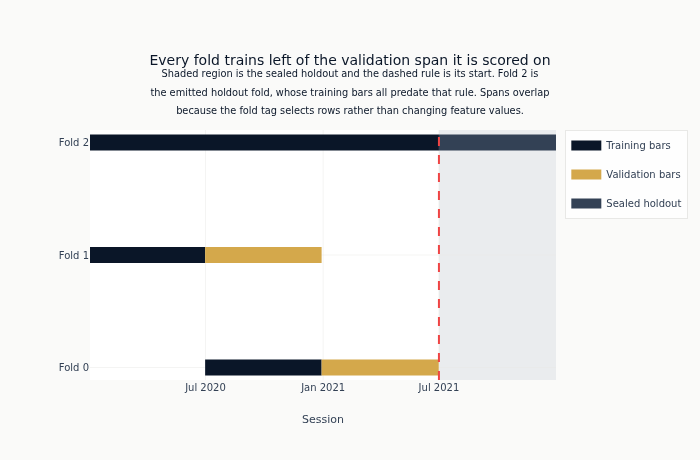

In [26]:
# One row per fold: training bars, then validation bars. The last row is the
# emitted holdout fold, which trains on every pre-holdout bar.
spans = [
    (f"Fold {s['fold']}", kind, iso(s[f"{key}_start"]), iso(s[f"{key}_end"]))
    for s in splits
    for kind, key in (("Training bars", "train"), ("Validation bars", "val"))
]
spans += [
    (
        f"Fold {len(splits)}",
        "Training bars",
        iso(min(s["train_start"] for s in splits)),
        iso(HOLDOUT_START),
    ),
    (f"Fold {len(splits)}", "Sealed holdout", iso(HOLDOUT_START), iso(HOLDOUT_END)),
]
span_colors = {
    "Training bars": COLORS["blue"],
    "Validation bars": COLORS["amber"],
    "Sealed holdout": COLORS["neutral"],
}

fig = go.Figure()
seen = set()
for row, kind, start, end in spans:
    fig.add_trace(
        go.Scatter(
            x=[start, end],
            y=[row, row],
            mode="lines",
            line={"width": 16, "color": span_colors[kind]},
            name=kind,
            legendgroup=kind,
            showlegend=kind not in seen,
        )
    )
    seen.add(kind)

fig.add_vrect(
    x0=iso(HOLDOUT_START),
    x1=iso(HOLDOUT_END),
    fillcolor=COLORS["neutral"],
    opacity=0.10,
    line_width=0,
    layer="below",
)
fig.add_vline(x=iso(HOLDOUT_START), line_dash="dash", line_color=COLORS["negative"])
fig.update_layout(
    # Plotly centres a title and clips whatever runs past the figure width, so a one-line <sup>
    # loses text off both ends. Every subtitle in this notebook is broken by hand for that reason.
    title=(
        "Every fold trains left of the validation span it is scored on"
        "<br><sup>Shaded region is the sealed holdout and the dashed rule is its start. Fold 2 is"
        "<br>the emitted holdout fold, whose training bars all predate that rule. Spans overlap"
        "<br>because the fold tag selects rows rather than changing feature values.</sup>"
    ),
    xaxis_title="Session",
    yaxis_title="",
    # Three subtitle lines need the room; at height=360 the last one landed on the Fold 2 bar.
    height=460,
    margin={"l": 90, "t": 130},
)
fig.show()

## 8. Join Validation

Verify that temporal features join correctly with Ch8 features and Ch7 labels.
This confirms compatible keys (`timestamp`, `symbol`) and overlapping row counts.

In [27]:
labels_path = CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet"
features_path = CASE_DIR / "features" / "financial.parquet"

if labels_path.exists() and features_path.exists():
    labels_keys = pl.scan_parquet(labels_path).select("timestamp", "symbol").collect()
    features_keys = pl.scan_parquet(features_path).select("timestamp", "symbol").collect()
    temporal_keys = temporal_clean.select("timestamp", "symbol")

    label_feat = features_keys.join(labels_keys, on=["timestamp", "symbol"], how="inner")
    full_join = label_feat.join(temporal_keys, on=["timestamp", "symbol"], how="inner")

    print(f"Labels rows:   {len(labels_keys):>12,}")
    print(f"Features rows: {len(features_keys):>12,}")
    print(f"Temporal rows: {len(temporal_keys):>12,}")
    print(f"All-three join:{len(full_join):>12,}")
    print(f"Join coverage:  {len(full_join) / len(temporal_keys) * 100:.1f}% of temporal rows")
else:
    print(
        "Upstream artifacts not yet available — run 02_labels.py and 03_financial_features.py first"
    )

Labels rows:     19,142,250
Features rows:   16,726,378
Temporal rows:   19,884,376
All-three join:  15,958,408
Join coverage:  80.3% of temporal rows


## 9. What the HAR Model Inferred

The HAR forecast is the only quantity here produced by a fitted model rather
than a fixed transform, so it is the one worth looking at directly. Figure F2
shows it against the realized volatility it forecasts, on validation rows
only, with the fold boundary marked.

At the level of a daily cross-sectional median the two series are close, and where they part it
is the forecast that runs higher. That is the same unconstrained linear extrapolation described
in Section 2, seen from the other side: a regression on a variance with nothing holding it down
overshoots a jump rather than lagging it.

The realized series is reconstructed exactly from what the notebook emits:
`har_residual[t] = rv_5[t] - har_forecast[t-1]`, so
`rv_5[t] = har_forecast[t-1] + har_residual[t]`. Both series are shown as the
cross-sectional median over symbols per session, because a single symbol's
minute-level realized variance is too noisy to read at this span.

In [28]:
har_view = (
    validation_rows(temporal_clean.select("timestamp", "symbol", "har_rv5_pred", "har_residual"))
    .sort(["symbol", "timestamp"])
    .with_columns(realized=pl.col("har_rv5_pred").shift(1).over("symbol") + pl.col("har_residual"))
    .with_columns(session=pl.col("timestamp").dt.date())
    .group_by("session")
    .agg(
        pl.col("har_rv5_pred").median().alias("forecast"),
        pl.col("realized").median().alias("realized"),
    )
    .sort("session")
)
print(f"Validation sessions plotted: {len(har_view):,}")

Validation sessions plotted: 253


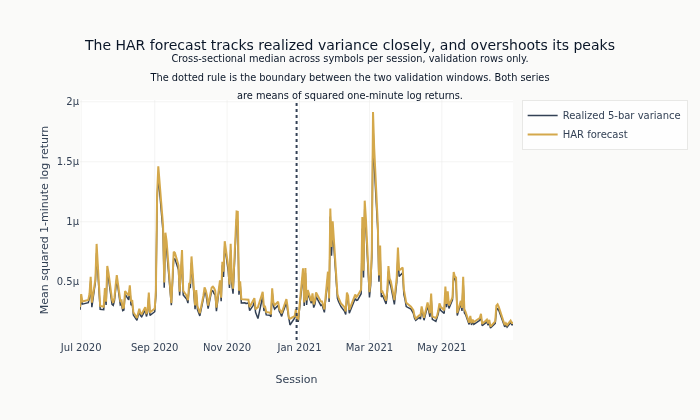

In [29]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=har_view["session"],
        y=har_view["realized"],
        mode="lines",
        name="Realized 5-bar variance",
        line={"color": COLORS["neutral"], "width": 1.5},
    )
)
fig.add_trace(
    go.Scatter(
        x=har_view["session"],
        y=har_view["forecast"],
        mode="lines",
        name="HAR forecast",
        line={"color": COLORS["amber"], "width": 2},
    )
)
# `splits` arrives in descending recency, so `splits[1:]` dropped the *latest* fold's boundary and
# drew the earliest one - which is the left edge of the plot, where there is nothing to separate.
# Sorting first and dropping the earliest puts the rule where one fold's parameters give way to
# the next.
for s in sorted(splits, key=lambda s: pd.Timestamp(s["val_start"]))[1:]:
    fig.add_vline(x=iso(s["val_start"]), line_dash="dot", line_color=COLORS["neutral"])
fig.update_layout(
    title=(
        "The HAR forecast tracks realized variance closely, and overshoots its peaks"
        "<br><sup>Cross-sectional median across symbols per session, validation rows only."
        "<br>The dotted rule is the boundary between the two validation windows. Both series"
        "<br>are means of squared one-minute log returns.</sup>"
    ),
    xaxis_title="Session",
    yaxis_title="Mean squared 1-minute log return",
    height=420,
)
fig.show()

## 10. Fit Stability Across Folds

The HAR is refitted every bar, so "stability across folds" is a question about
the distribution of the rolling coefficients rather than about three numbers
per fold. Figure F3 shows that distribution per fold. A component whose
coefficient is centred near zero in every fold is telling the reader that the
horizon it represents is not carrying information at this frequency.

In [30]:
beta_by_fold = validation_rows(
    har_beta_df.select("timestamp", "symbol", "beta_5", "beta_15", "beta_60")
)
beta_long = beta_by_fold.unpivot(
    index=["fold"],
    on=["beta_5", "beta_15", "beta_60"],
    variable_name="component",
    value_name="coefficient",
)

beta_summary = (
    beta_long.group_by(["fold", "component"])
    .agg(
        pl.col("coefficient").median().alias("median"),
        pl.col("coefficient").quantile(0.25).alias("q25"),
        pl.col("coefficient").quantile(0.75).alias("q75"),
        pl.len().alias("n_fits"),
    )
    .sort(["component", "fold"])
)
print(beta_summary)

shape: (6, 6)
┌──────┬───────────┬───────────┬───────────┬──────────┬────────┐
│ fold ┆ component ┆ median    ┆ q25       ┆ q75      ┆ n_fits │
│ ---  ┆ ---       ┆ ---       ┆ ---       ┆ ---      ┆ ---    │
│ i32  ┆ str       ┆ f64       ┆ f64       ┆ f64      ┆ u32    │
╞══════╪═══════════╪═══════════╪═══════════╪══════════╪════════╡
│ 0    ┆ beta_15   ┆ -0.005918 ┆ -0.098867 ┆ 0.097283 ┆ 12827  │
│ 1    ┆ beta_15   ┆ -0.021675 ┆ -0.112309 ┆ 0.080591 ┆ 12846  │
│ 0    ┆ beta_5    ┆ 0.828572  ┆ 0.776116  ┆ 0.881998 ┆ 12827  │
│ 1    ┆ beta_5    ┆ 0.82412   ┆ 0.774892  ┆ 0.872185 ┆ 12846  │
│ 0    ┆ beta_60   ┆ -0.087009 ┆ -0.263951 ┆ 0.120942 ┆ 12827  │
│ 1    ┆ beta_60   ┆ -0.060376 ┆ -0.249    ┆ 0.153486 ┆ 12846  │
└──────┴───────────┴───────────┴───────────┴──────────┴────────┘


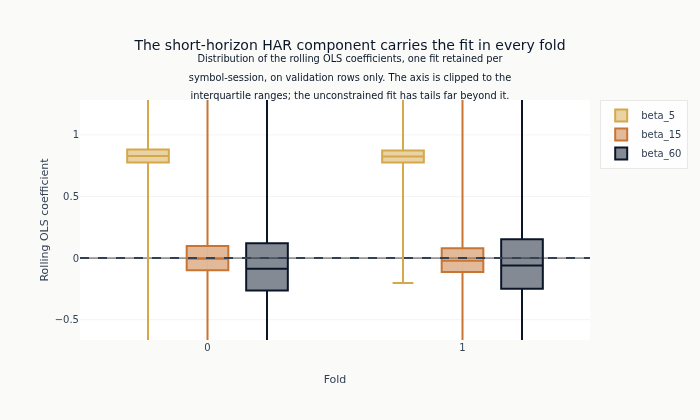

In [31]:
fig = go.Figure()
_component_colors = {
    "beta_5": COLORS["amber"],
    "beta_15": COLORS["copper"],
    "beta_60": COLORS["blue"],
}
for component, color in _component_colors.items():
    part = beta_long.filter(pl.col("component") == component)
    fig.add_trace(
        go.Box(
            x=part["fold"],
            y=part["coefficient"],
            name=component,
            marker_color=color,
            boxpoints=False,
        )
    )
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
# The rolling OLS is unconstrained on a variance, so a handful of the 25,673 fits run to three
# figures and a single whisker sets a y-range of roughly [-250, 1500] - on which all six boxes
# collapse onto the zero line and the figure shows nothing. The axis is clipped to the quartiles
# it is about, with the padding taken from the data rather than typed, and the subtitle says so.
_q_low = beta_summary["q25"].min()
_q_high = beta_summary["q75"].max()
_pad = 0.35 * (_q_high - _q_low)
fig.update_layout(
    title=(
        "The short-horizon HAR component carries the fit in every fold"
        "<br><sup>Distribution of the rolling OLS coefficients, one fit retained per"
        "<br>symbol-session, on validation rows only. The axis is clipped to the"
        "<br>interquartile ranges; the unconstrained fit has tails far beyond it.</sup>"
    ),
    xaxis_title="Fold",
    yaxis_title="Rolling OLS coefficient",
    yaxis_range=[_q_low - _pad, _q_high + _pad],
    boxmode="group",
    height=420,
)
fig.show()

## 11. Validation IC of the Temporal Features

Does a temporal feature rank the cross-section on its own? We compute the
Information Coefficient — cross-sectional Spearman rank correlation between
each feature and the primary label — then apply HAC standard errors and a
Benjamini-Hochberg correction across the features tested.

**This selects nothing.** It is a screen on validation rows that says whether
a feature carries any stand-alone cross-sectional signal. The comparison
against the Ch8 financial features, and any decision that follows from it, is
run in `05_evaluation`.

Three constraints make this readout mean what it says:

1. **Validation rows only.** The features carry no fold column, so the frame
   is routed through `validation_rows` and the holdout is never scored.
2. **The IC series is chronological.** `cross_sectional_ic_series` sorts its
   dates internally. A per-date IC series assembled by grouping arrives in
   arbitrary order, and a Newey-West correction computed over a permutation of
   time reports no autocorrelation where there is plenty.
3. **The HAC bandwidth is the automatic rule.** Timestamps are thinned to one
   per label horizon, so consecutive IC observations share no return window.
   That removes the mechanical floor the overlap would otherwise put under the
   lag, and the bandwidth falls back to the Newey-West rule of thumb,
   $\lfloor 4 (T/100)^{2/9} \rfloor$ on the $T$ observations of the sampled
   series. Non-overlapping is not the same as independent, so the lag is left
   to that rule rather than pinned; the value it picks is printed below.

In [32]:
if not labels_path.exists():
    raise FileNotFoundError(f"Labels not available — run 02_labels.py first ({labels_path}).")

labels_primary = pl.read_parquet(labels_path)
eval_df = validation_rows(temporal_clean).join(
    labels_primary, on=["timestamp", "symbol"], how="inner"
)
print(f"Validation rows with a label: {len(eval_df):,}")
print(f"Validation span: {eval_df['timestamp'].min()} .. {eval_df['timestamp'].max()}")
assert eval_df["timestamp"].max() < HOLDOUT_START, "IC evaluation reached into the holdout"

# Thin to one decision per label horizon so consecutive IC observations do not
# share a return window. Selected by semi-join: `is_in` against a Series of the
# same dtype is ambiguous and changes meaning in a later Polars.
sample_ts = eval_df["timestamp"].unique().sort().gather_every(IC_SAMPLE_STEP)
eval_sample = eval_df.join(sample_ts.to_frame("timestamp"), on="timestamp", how="semi")
print(f"Sampled {len(sample_ts):,} timestamps ({len(eval_sample):,} rows)")

Validation rows with a label: 9,607,099
Validation span: 2020-06-30 11:32:00 .. 2021-06-30 15:44:00
Sampled 6,317 timestamps (640,506 rows)


In [33]:
# One IC series per feature, from the library call that sorts its dates.
n_symbols = eval_sample["symbol"].n_unique()
min_cs_size = min(10, n_symbols)

ic_data = {}
for feat in temporal_feature_cols:
    frame = eval_sample.select("timestamp", "symbol", feat, PRIMARY_LABEL).drop_nulls()
    if frame.is_empty():
        continue
    ic_by_ts = cross_sectional_ic_series(
        frame,
        frame,
        pred_col=feat,
        ret_col=PRIMARY_LABEL,
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=min_cs_size,
    )
    if len(ic_by_ts) >= 20:
        ic_data[feat] = ic_by_ts

print(f"IC series computed for {len(ic_data)}/{len(temporal_feature_cols)} features")

IC series computed for 22/22 features


### HAC-Adjusted Significance + FDR

Apply Newey-West HAC standard errors and Benjamini-Hochberg FDR correction
to the temporal feature IC series.

In [34]:
# The label horizon expressed in steps of the sampled series. Thinning is one step
# per label horizon, so this is 1: consecutive observations do not overlap, the
# overlap floor `label_horizon - 1` is zero, and the helper is left with its
# automatic bandwidth. `effective_lags` below reports what that came out at.
IC_LABEL_HORIZON = max(1, -(-LABEL_HORIZON_BARS // IC_SAMPLE_STEP))

hac_rows = []
for feat, ic_df in ic_data.items():
    stats = compute_ic_hac_stats(ic_df, ic_col="ic", label_horizon=IC_LABEL_HORIZON)
    stats["feature"] = feat
    hac_rows.append(stats)

if hac_rows:
    hac_df = pl.DataFrame(hac_rows)
    p_values = hac_df["p_value"].to_list()
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    hac_df = hac_df.with_columns(fdr_significant=pl.Series(fdr_result["rejected"].tolist()))
    hac_df = hac_df.sort(pl.col("mean_ic").abs(), descending=True)
else:
    hac_df = pl.DataFrame(
        schema={
            "feature": pl.Utf8,
            "mean_ic": pl.Float64,
            "hac_se": pl.Float64,
            "t_stat": pl.Float64,
            "p_value": pl.Float64,
            "naive_t_stat": pl.Float64,
            "fdr_significant": pl.Boolean,
        }
    )

In [35]:
n_tested = len(hac_df)
n_naive_sig = (
    int(hac_df.filter(pl.col("naive_t_stat").abs() > 1.96).shape[0]) if n_tested > 0 else 0
)
n_fdr_sig = int(hac_df.filter(pl.col("fdr_significant")).shape[0]) if n_tested > 0 else 0
if n_tested > 0:
    _hac_mean = hac_df["t_stat"].abs().mean()
    inflation = (
        round(float(hac_df["naive_t_stat"].abs().mean() / _hac_mean), 2)
        if _hac_mean and _hac_mean > 0
        else 1.0
    )
    # The bandwidth the correction actually ran at. Series lengths differ across
    # features, so the automatic rule can land on different lags; report the range.
    _lag_lo = int(hac_df["effective_lags"].min())
    _lag_hi = int(hac_df["effective_lags"].max())
    hac_lags = f"{_lag_lo}" if _lag_lo == _lag_hi else f"{_lag_lo}-{_lag_hi}"
else:
    inflation = 1.0
    hac_lags = "none"

print(f"\nTemporal features tested: {n_tested}")
print(f"Naive significant (|t|>1.96): {n_naive_sig}")
print(f"FDR significant (alpha=0.05): {n_fdr_sig}")
print(f"HAC lags in use (automatic bandwidth): {hac_lags}")
print(f"Inflation factor (naive/HAC): {inflation:.1f}x")


Temporal features tested: 22
Naive significant (|t|>1.96): 3
FDR significant (alpha=0.05): 3
HAC lags in use (automatic bandwidth): 10
Inflation factor (naive/HAC): 1.0x


**Figure F4** replaces the ranked table this section used to print. Each bar is
a feature's mean validation IC with its HAC confidence interval; a bar is
colored when the FDR correction retains the feature and neutral when it does
not. The interval is what stops the ranking from being read as a result: the
features are ordered by point estimate, and most of those estimates cannot be
distinguished from zero.

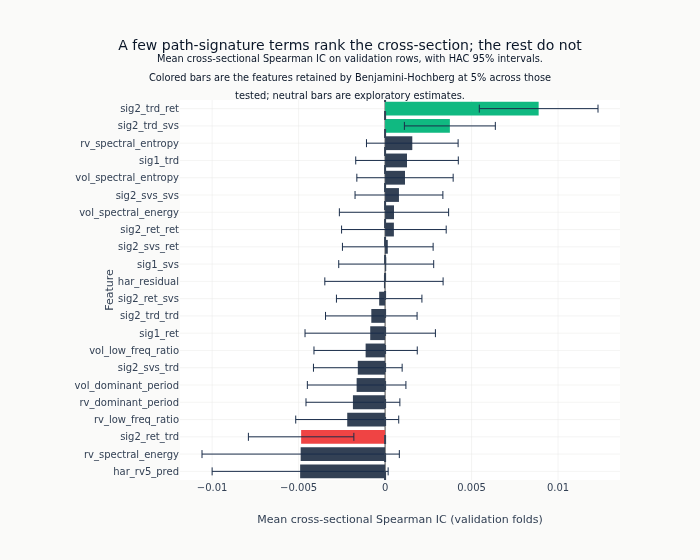

In [36]:
if n_tested > 0:
    plot_ic = hac_df.sort("mean_ic")
    bar_colors = [
        COLORS["positive"]
        if row["fdr_significant"] and row["mean_ic"] > 0
        else COLORS["negative"]
        if row["fdr_significant"]
        else COLORS["neutral"]
        for row in plot_ic.to_dicts()
    ]
    ic_title = (
        "A few path-signature terms rank the cross-section; the rest do not"
        if n_fdr_sig
        else "No temporal feature ranks the cross-section on its own"
    ) + (
        "<br><sup>Mean cross-sectional Spearman IC on validation rows, with HAC 95% intervals."
        "<br>Colored bars are the features retained by Benjamini-Hochberg at 5% across those"
        "<br>tested; neutral bars are exploratory estimates.</sup>"
    )
    fig = go.Figure(
        go.Bar(
            x=plot_ic["mean_ic"],
            y=plot_ic["feature"],
            orientation="h",
            marker_color=bar_colors,
            error_x={
                "type": "data",
                "array": (1.96 * plot_ic["hac_se"]).to_list(),
                "color": COLORS["slate"],
                "thickness": 1,
            },
            showlegend=False,
        )
    )
    fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
    fig.update_layout(
        title=ic_title,
        xaxis_title="Mean cross-sectional Spearman IC (validation folds)",
        yaxis_title="Feature",
        margin={"l": 180},
        height=560,
    )
    fig.show()
else:
    print("Validation IC chart omitted: too few symbols per timestamp to rank a cross-section.")

### What the validation screen found

Of the temporal features tested on validation rows, the count retained by
Benjamini-Hochberg at 5% is printed above and drawn in F4. The HAC-to-naive
inflation factor reports how much of the apparent significance was an artifact
of serial correlation in the IC series.

**Read it against the lag it was computed at, which is printed above.** The
correction ran at the automatic Newey-West bandwidth, over that many lags of the
sampled IC series. Thinning to one decision per label horizon removed the
overlap that would have forced a wider lag, but it is no reason to assume the
series is serially independent, so the bandwidth was left to the automatic rule
rather than pinned to one.

That is what makes a factor near one worth something here: Newey-West looked out
over the printed number of lags and found little left to widen the standard error
by, so the thinning removed the autocorrelation the overlap induces rather than
hiding it. A correction pinned to a single lag could not have told us that.

The reading to be careful about is a factor near one on returns that do
overlap — which is what a per-date IC series assembled by `group_by` produces,
because the series reaches the HAC helper in arbitrary order and reports no
autocorrelation where there is plenty. That is why the series here comes from
`cross_sectional_ic_series`, which sorts its dates.

**This screen selects nothing.** Whether the temporal block adds anything over
the Ch8 financial features is a comparison run on the same validation rows in
`05_evaluation`; nothing downstream reads a decision from this section.

## 12. Tag with CV Folds and Save

The temporal features (HAR, FFT, signatures) are inherently causal — each
value depends only on a trailing window of past data — so the computed
feature values are identical regardless of fold. We still tag rows with a
`fold` column so that downstream `load_modeling_dataset` can provide
per-fold temporal features to training functions.

For each fold we include **train + test** rows (not test-only) because
downstream models need temporal features for the full fold period.

In [37]:
# Folds were resolved in Section 7; nothing here re-derives them.
fold_frames = []

for s in splits:
    train_start = pd.Timestamp(s["train_start"])
    val_end = pd.Timestamp(s["val_end"])
    fold_df = temporal_clean.filter(
        (pl.col("timestamp") >= train_start) & (pl.col("timestamp") <= val_end)
    ).with_columns(pl.lit(s["fold"]).alias("fold"))
    fold_frames.append(fold_df)
    print(f"  Fold {s['fold']}: {len(fold_df):,} rows (train+validation)")

# Folds arrive in descending recency, so the earliest training bar is the
# minimum across folds rather than the last one's.
holdout_fold_idx = len(splits)
earliest_train_start = (
    min(pd.Timestamp(s["train_start"]) for s in splits) if splits else HOLDOUT_START
)
holdout_df = temporal_clean.filter(
    (pl.col("timestamp") >= earliest_train_start) & (pl.col("timestamp") <= HOLDOUT_END)
).with_columns(pl.lit(holdout_fold_idx).alias("fold"))
fold_frames.append(holdout_df)
print(f"  Holdout fold {holdout_fold_idx}: {len(holdout_df):,} rows")

temporal_with_folds = pl.concat(fold_frames)
print(
    f"\nTotal with folds: {len(temporal_with_folds):,} rows "
    f"({temporal_with_folds['fold'].n_unique()} folds)"
)

  Fold 0: 9,991,017 rows (train+validation)


  Fold 1: 9,946,908 rows (train+validation)


  Holdout fold 2: 19,845,766 rows

Total with folds: 39,783,691 rows (3 folds)


In [38]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

output_path = FEATURES_DIR / "model_based.parquet"
temporal_with_folds.write_parquet(output_path)
print(f"Saved: {output_path} ({output_path.stat().st_size / 1e6:.1f} MB)")

Saved: ~/ml4t/public-s15-6/case_studies/nasdaq100_microstructure/features/model_based.parquet (6142.3 MB)


Reconcile the artifact against the frame it was built from, so that a key or
fold error fails here rather than in the first model that reads it.

In [39]:
_written = pl.scan_parquet(output_path)
assert _written.select(pl.len()).collect().item() == len(temporal_with_folds)
assert temporal_with_folds.select(
    pl.struct("timestamp", "symbol", "fold").n_unique()
).item() == len(temporal_with_folds), (
    "duplicate (timestamp, symbol, fold) key in the emitted artifact"
)
assert set(temporal_with_folds["fold"].unique().to_list()) == set(range(len(splits) + 1))
print(f"Artifact reconciled: {len(temporal_with_folds):,} rows, {len(splits) + 1} folds")

Artifact reconciled: 39,783,691 rows, 3 folds


## Key Takeaways

### Three Temporal Models for Intraday Microstructure

| Model | Features | Signal Type | Window |
|-------|----------|-------------|--------|
| HAR(5,15,60) | Conditional vol, residual | Multi-horizon vol dynamics | 120-bar OLS |
| FFT | Energy, period, entropy | Frequency structure | 60-bar rolling |
| Path Signatures | 12 depth-2 terms | Path geometry (lead-lag) | 30-bar trailing |

### Implementation Highlights

1. **HAR adapted for intraday**: Uses 5/15/60-minute components instead of
   daily/weekly/monthly. Walk-forward OLS avoids look-ahead bias
2. **Dual FFT targets**: Volume and volatility have different spectral
   signatures -- volume has strong intraday periodicity (U-shape), while
   volatility clustering shows in lower frequencies
3. **Manual signatures**: Depth-2 closed-form implementation avoids library
   dependencies. Cross-terms (e.g., sig2_ret_svs) capture whether price
   moved before or after order flow -- the key microstructure question
4. **Walk-forward discipline**: HAR is fitted on rolling windows. FFT and
   signatures are inherently causal (use only trailing data)

### Feature Evaluation

5. **Resolve the folds before you evaluate anything.** These features carry no
   fold column of their own, so any readout built from the feature frame spans
   whatever the frame spans — including the sealed holdout. Section 7 resolves
   the folds first and every readout below it goes through `validation_rows`.
6. **A per-date IC series has to be in date order.** Newey-West treats row
   order as time order and does not sort, while a Polars `group_by` returns
   groups in arbitrary order. The two together silently report a HAC standard
   error computed over a permutation of time, and the tell is an inflation
   factor near one on returns that overlap. This notebook sorts through
   `cross_sectional_ic_series` and thins to one decision per label horizon, so a
   low factor here is a reading taken at the automatic bandwidth, not that tell.

### Known Limitations

7. **The HAR forecast is unconstrained.** It is a linear regression on a
   variance with nothing holding it above zero, so a symbol-level shock outside
   the trailing window's range extrapolates to a negative forecast. The share
   is small and measured in Section 2, but the column's mean and standard
   deviation are set by those rows and should not be read as a description of
   the feature. Modeling log-variance is the standard remedy; this notebook
   leaves the forecast unconstrained so the failure mode stays visible.
8. **Aggregation windows cross session boundaries.** `r1m` is session-bounded,
   but the trailing HAR, FFT and signature windows are not; the affected share
   is measured in Section 2 and grows with the window.

**Next**: Ch11+ combines Ch8 cross-sectional features with Ch9 temporal
features for model training. The comparison of this feature block against the
Ch8 financial features happens there, on the same validation rows.